## Model Used: Random Forest

In [20]:
## Load Data, import required libraries, sklearn and matplot
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

path = "C:\Datasets" 

##Read data file
filename_read = os.path.join(path, "energydata_complete.csv")
data = pd.read_csv(filename_read)

print(data.head())
print(data.shape)
# data.info()

## SET target column, column 'Appliances'
target = "Appliances"

## DROP date column, string
## TARGET from X
X = data.drop(columns=["date", target]).values
y = data[target].values

## Train:Test split ( 25% test size ) + reproducable random state, 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

In [21]:
r2_list = []
mae_list = []
nums = []

rf = RandomForestRegressor(
    n_estimators=1,
    random_state=42,
    n_jobs=-1,
    warm_start=True
)

## Loop over trees 
for i in range(1, 129):
    rf.set_params(n_estimators=i)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    nums.append(i)
    r2_list.append(r2)
    mae_list.append(mae)

## No. of descision trees
print(f"Trees: {i:3d}")
##
print(f"R2: {r2:.4f}")
##
print(f"R2: {mae:.3f}")


Trees: 128
R2: 0.5216
R2: 32.925


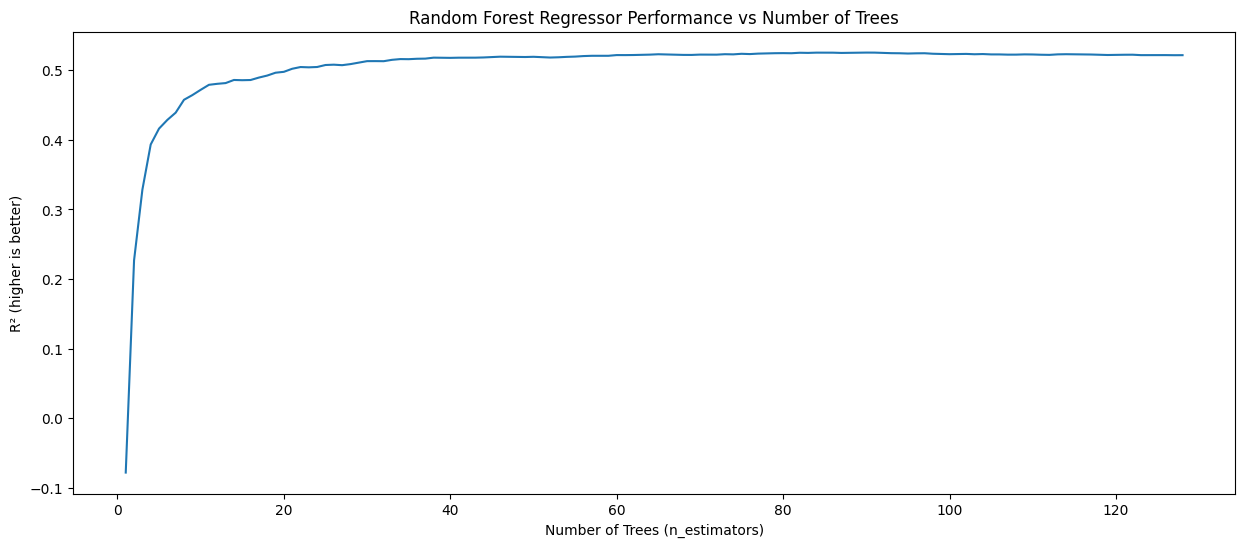

In [24]:
## Plot 
plt.figure(figsize=(15, 6))
plt.plot(nums, r2_list)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("R² (higher is better)")
plt.title("Random Forest Regressor Performance vs Number of Trees")
plt.show()

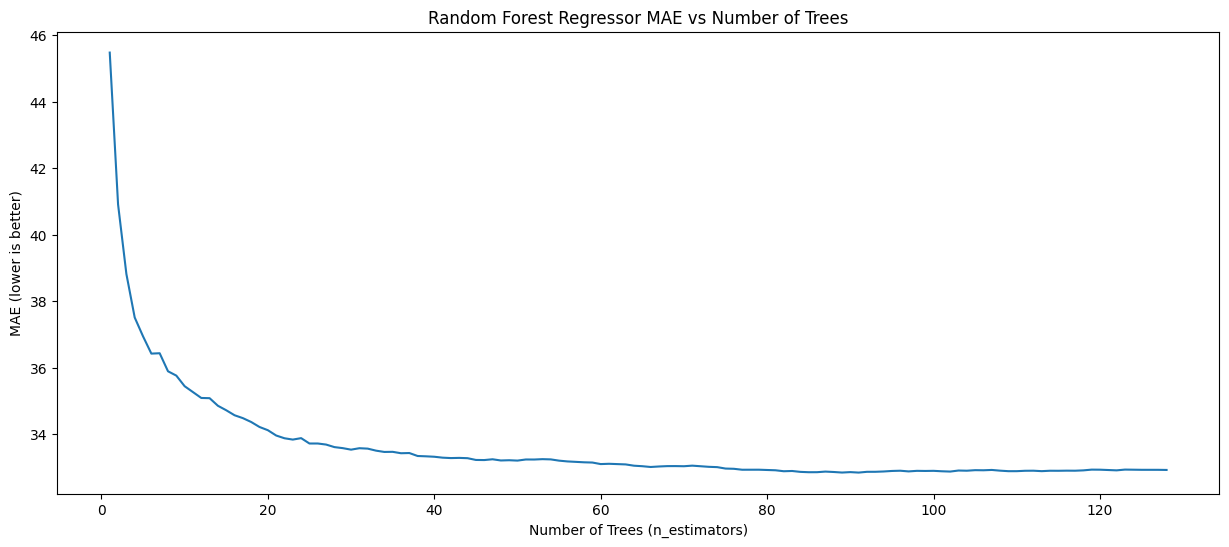

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(nums, mae_list)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("MAE (lower is better)")
plt.title("Random Forest Regressor MAE vs Number of Trees")
plt.show()

# Note:  No. of trees used is expotential to the level of accuracy up until about 20 trees where it starts to stagnate.